# Missing Data & Data Quality Checks

This lecture covers:
- **Data Validation:** Checking data types, missing values, and basic consistency.
- **Missing Data Handling:** Options to drop or impute missing data.
- **Visualization:** Using heatmaps and histograms to understand data distribution.

In [2]:
import pandas as pd            # Data handling
import seaborn as sns          # Plotting library for statistical data visualization
import matplotlib.pyplot as plt  # Plotting library for custom graphs

## Load the Dataset

In [4]:
# Read the Titanic dataset from a CSV file into a pandas DataFrame.
df = pd.read_csv("titanic.csv")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0,0,0,24160,211.3375,B5,S,2,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,NaN,1,2,113781,151.5500,C22 C26,S,11,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,NaN,1,2,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1,2,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1,2,113781,151.5500,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"


## Display Summary Statistics

In [5]:
# Use .describe() to generate statistical summaries (mean, std, count, etc.).
df.describe()

,pclass,survived,age,sibsp,parch,fare
count,1309.000000,1309.000000,862.000000,1309.000000,1309.000000,1308.000000
mean,2.294882,0.381971,33.439675,0.498854,0.385027,33.295479
std,0.837836,0.486055,12.251259,1.041658,0.865560,51.758668
min,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,24.000000,0.000000,0.000000,7.895800
50%,3.000000,0.000000,30.000000,0.000000,0.000000,14.454200
75%,3.000000,1.000000,41.000000,1.000000,0.000000,31.275000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200


<Axes: >

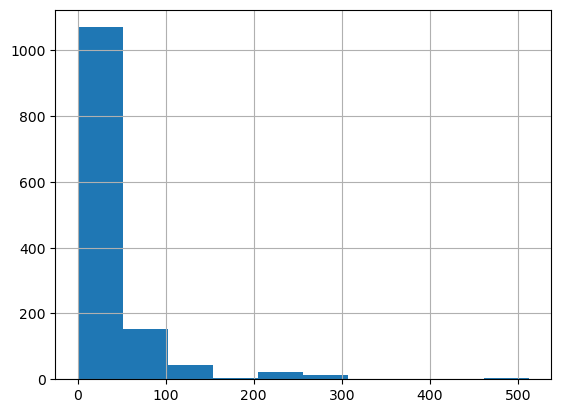

In [6]:
df['fare'].hist()

## Check for Missing Values

In [8]:
# Compute the sum of missing values per column and display the result.
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           447
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
home.dest     564
dtype: int64

## Visualize Missing Data with a Heatmap

<Axes: >

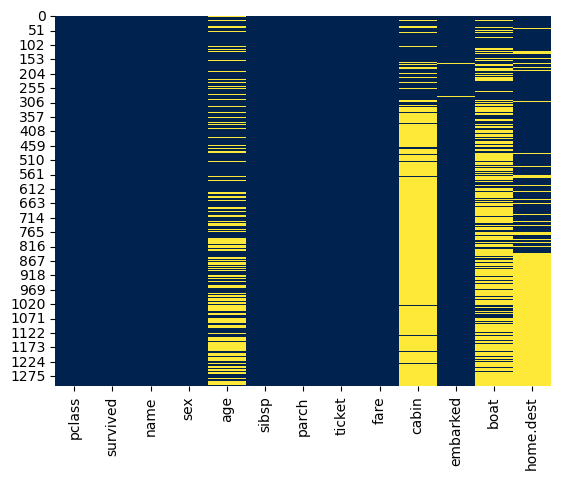

In [11]:
# Create a heatmap where missing values are highlighted.
# Hint: use plt.subplots(), sns.heatmap(), and plt.show()
sns.heatmap(df.isnull(), cmap = "cividis", cbar=False)

## Handle Missing Data

We will explore different methods for handling missing data on a single column.

**Change the variable below to explore different numeric columns.**

In [13]:
# Choose a numeric column to work with.
column = "age"

print(f"Numeric columns available: {list(df.select_dtypes(include=['number']).columns)}")
print(f"\nCurrently selected: {column}")
print(f"Missing values in {column}: {df[column].isnull().sum()}")

Numeric columns available: ['pclass', 'survived', 'age', 'sibsp', 'parch', 'fare']

Currently selected: age
Missing values in age: 447


### Original Data Distribution

<Axes: xlabel='age', ylabel='Count'>

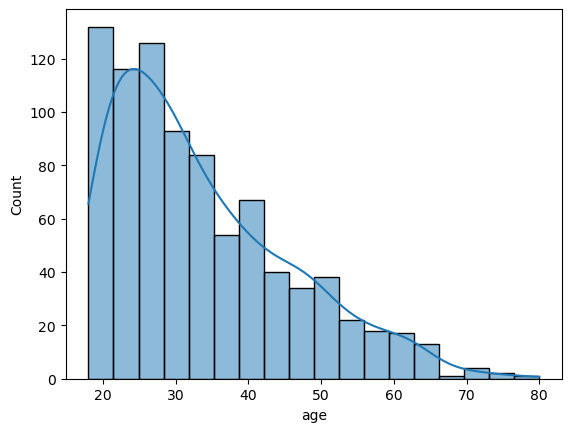

In [14]:
# Plot a histogram (with a KDE) for the selected column.
# Then display the statistical summary using .describe().
sns.histplot(df[column], kde = True)

### Method 1: Drop Rows

Remove all rows that contain any missing values.

In [ ]:
# Create a copy of the DataFrame, then drop rows with missing values using .dropna().
# Compare the original and cleaned distributions side by side.
# Hint: use plt.subplots(1, 2, figsize=(12, 4)) for side-by-side plots.


### Method 2: Drop Columns (>50% Missing)

Drop columns where more than 50% of the values are missing.

In [ ]:
# Create a copy, then drop columns with more than 50% missing.
# Hint: use .isnull().mean() to find the fraction of missing values per column.
# Print the original and remaining columns to see what was dropped.


### Method 3: Impute with Mean

Replace missing values in the selected column with the column's mean.

<Axes: xlabel='age', ylabel='Count'>

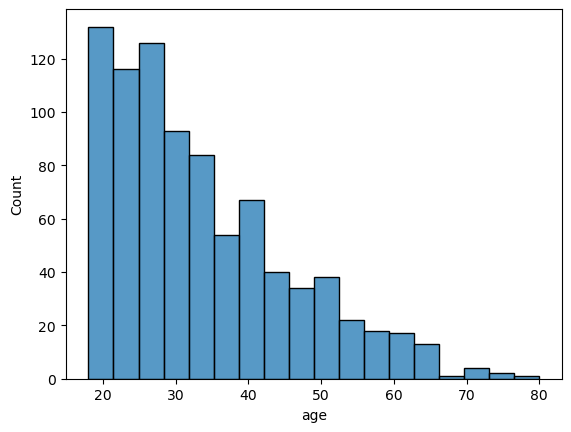

In [17]:
sns.histplot(df[column])

<Axes: xlabel='age', ylabel='Count'>

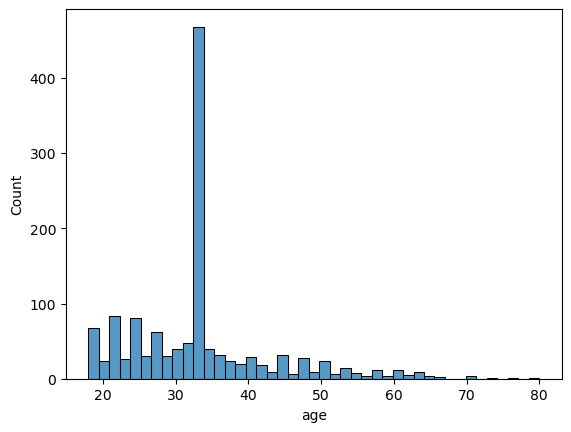

In [18]:
# Create a copy, then fill missing values with the mean using .fillna().
# Compare the original and imputed distributions side by side.
df_copy = df.copy()
df_copy[column] = df_copy[column].fillna(df[column].mean())
sns.histplot(df_copy[column])

### Method 4: Impute with Median

Replace missing values in the selected column with the column's median.

<Axes: xlabel='age', ylabel='Count'>

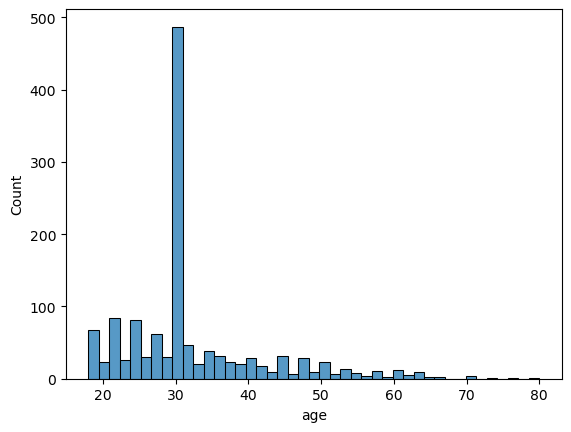

In [19]:
# Create a copy, then fill missing values with the median using .fillna().
# Compare the original and imputed distributions side by side.
df_copy = df.copy()
df_copy[column] = df_copy[column].fillna(df[column].median())
sns.histplot(df_copy[column])

### Method 5: Impute with Zero

Replace missing values in the selected column with zero.

<Axes: xlabel='age', ylabel='Count'>

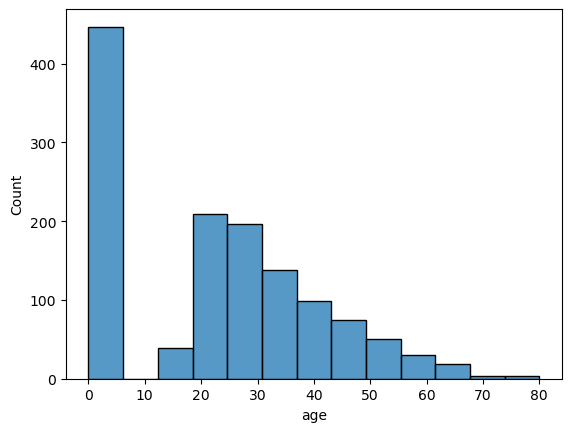

In [20]:
# Create a copy, then fill missing values with 0 using .fillna().
# Compare the original and imputed distributions side by side.
df_copy = df.copy()
df_copy[column] = df_copy[column].fillna(0)
sns.histplot(df_copy[column])